# 14 Entrenamiento

**Tarea "copia":** $\;$ el modelo debe aprender a copiar la secuencia aleatoria de símbolos dada

**Batching y masking:** $\;$ consiste en preparar datos y máscaras asociadas para entrenar el modelo

**`data_generator`:** $\;$ generador de datos sintéticos basado en una clase `Batch` para batching y masking

In [1]:
import torch; import torch.nn as nn; torch.manual_seed(23)
import import_ipynb; from at2523 import data_generator

In [2]:
V = 11; num_batches = 1; batch_size = 1
data_iter = data_generator(V, batch_size, nbatches=num_batches)
for i, batch in enumerate(data_iter):
    print(f"Batch {i}:")
    print(f"src:", str(batch['src']).replace('\n',''))
    print(f"src_mask:", str(batch['src_mask']).replace('\n',''))
    print(f"tgt:", str(batch['tgt']).replace('\n','')) # decoder input
    print(f"tgt_y:", str({batch['tgt_y']}).replace('\n','')) # decoder target
    print(f"tgt_mask:\n", batch['tgt_mask'])
    print(f"num_tokens:", batch['num_tokens'].item())

Batch 0:
src: tensor([[1, 7, 7, 8, 1, 3, 8, 2, 5, 8]])
src_mask: tensor([[[True, True, True, True, True, True, True, True, True, True]]])
tgt: tensor([[1, 7, 7, 8, 1, 3, 8, 2, 5]])
tgt_y: {tensor([[7, 7, 8, 1, 3, 8, 2, 5, 8]])}
tgt_mask:
 tensor([[[ True, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False],
         [ True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False],
         [ True,  True,  True,  True,  True, False, False, False, False],
         [ True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True]]])
num_tokens: 9



<p style="page-break-after:always;"></p>


**Pérdida:** $\;$ [entropía cruzada](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss) de la predicción $\,\hat{\boldsymbol{y}}\,$ relativa a la referencia con [label smoothing](https://arxiv.org/abs/1512.00567), $\,\tilde{\boldsymbol{y}}$
$$\mathbb{H}(\hat{\boldsymbol{y}}, \tilde{\boldsymbol{y}})=-\sum_c\;\tilde{y}_c\log\hat{y}_c%
\qquad\text{donde}\qquad%
\tilde{\boldsymbol{y}}=(1-\epsilon)\,\boldsymbol{y}+\epsilon\,\frac{1}{C}\boldsymbol{1}_C%
\quad\text{con}\quad \epsilon=0.1$$

**Ejemplo:** $\;$ $C=2,\,\mathcal{C}=\{0,1\},\,\hat{\boldsymbol{y}}=(0.2123, 0.7877)^t,\,\boldsymbol{y}=(0.5738, 0.4262)^t$
$$\begin{align*}
\mathbb{H}(\hat{\boldsymbol{y}}, \boldsymbol{y})&=-0.5738\log 0.2123-0.4262\log 0.7877=0.9910\\[3mm]%
\tilde{\boldsymbol{y}}&=0.9\,\boldsymbol{y}+0.1\,(0.5, 0.5)^t=(0.5664, 0.4336)^t\\%
\mathbb{H}(\hat{\boldsymbol{y}}, \tilde{\boldsymbol{y}})&=-0.5664\log 0.2123-0.4336\log 0.7877=0.9813\\%
\end{align*}$$ 

In [3]:
import torch; import torch.nn as nn; torch.manual_seed(23); torch.set_printoptions(precision=4)
H = nn.CrossEntropyLoss(label_smoothing=0.0)
y_pred_logits = torch.randn(1, 2); print("y_pred_logits =", y_pred_logits)
y_pred_probs = y_pred_logits.softmax(dim=1); print("y_pred_probs =", y_pred_probs)
y_probs = torch.randn(1, 2).softmax(dim=1); print("y_probs =", y_probs)
print(f"H({y_pred_logits}, {y_probs}, epsilon=0.0) = ", H(y_pred_logits, y_probs))
H = nn.CrossEntropyLoss(label_smoothing=0.1)
print(f"H({y_pred_logits}, {y_probs}, epsilon=0.1) = ", H(y_pred_logits, y_probs))

y_pred_logits = tensor([[-0.8733,  0.4376]])
y_pred_probs = tensor([[0.2123, 0.7877]])
y_probs = tensor([[0.5738, 0.4262]])
H(tensor([[-0.8733,  0.4376]]), tensor([[0.5738, 0.4262]]), epsilon=0.0) =  tensor(0.9909)
H(tensor([[-0.8733,  0.4376]]), tensor([[0.5738, 0.4262]]), epsilon=0.1) =  tensor(0.9812)



<p style="page-break-after:always;"></p>


**Optimizador:** $\;$ [adaptive moment estimation (Adam)](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html) con $\,\beta_1=0.9,\,$ $\beta_2=0.98\,$ y $\,\epsilon=10^{-9};\;$ aunque actualmente se usa una versión mejorada, [Adam with decoupled weight decay (AdamW)](https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html):
* **Entrada:** $\;$ lr $\,\gamma,\,$ $\beta_1,\beta_2\in[0, 1),\,$ $\theta_0,\,$ objetivo estocástico a minimizar $\,f(\theta),\,$ weight decay $\,\lambda,\,$  $\epsilon$
* **Inicialización:** $\;$ primer momento $\,m_0 \leftarrow 0,\,$ segundo momento $\,v_0\leftarrow 0$
* **Iteración $\,i=1,\ldots\,$:**
    1. $g_i \leftarrow\nabla_{\theta} f_i (\theta_{i-1})$ $\quad$ (obtiene gradiente con respecto al objetivo estocástico en la iteración $i$)
    2. $m_i \leftarrow \beta_1\,m_{i-1} + (1-\beta_1)\,g_i$ $\quad$ (actualiza estimador sesgado del primer momento)
    3. $v_i \leftarrow \beta_2\,v_{i-1} + (1-\beta_2)\,g^2_i$ $\quad$ (actualiza estimador sesgado del segundo momento)
    4. $\widehat{m_i} \leftarrow m_i\,/\,\big(1-\beta_1^i \big)$ $\quad$ (corrige el sesgo del estimador del primer momento)
    5. $\widehat{v_i} \leftarrow v_i\,/\,\big(1-\beta_2^i \big)$ $\quad$ (corrige el sesgo del estimador del segundo momento)
    2. $\theta_{i-1} \leftarrow \theta_{i-1} - \gamma\,\lambda\,\theta_{i-1}$ $\quad$ (regularización mediante weight decay)
    7. $\theta_i \leftarrow \theta_{i-1} - \gamma\,\widehat{m_i}\,/\,\big(\sqrt{\widehat{v_i}} + \epsilon \big)$ $\quad$ (actualización de parámetros por gradiente normalizado)


<p style="page-break-after:always;"></p>


**Planificador original:** $\;$ incrementa el learning rate linealmente durante los primeros `warmup_steps` y luego lo decrementa proporcionalmente a la inversa de la raíz de `step_num`
$$lrate = d_{\text{model}}^{-0.5} \cdot \min({step\_num}^{-0.5}, {step\_num} \cdot {warmup\_steps}^{-1.5})$$

<div><table align="center"><tr><td style="border: none;"><img src="scheduler_orig.png"/></td></tr></table></div>

**Incoveniente del scheduler original:** $\;$ su dependencia del tamaño del modelo, lo que dificulta comparar modelos


<p style="page-break-after:always;"></p>


**Planificador actual:** $\;$ [cosine Annealing with Warmup](https://github.com/huggingface/transformers/blob/v4.56.0/src/transformers/optimization.py#L144) primero incrementa el learning rate linealmente, desde cero hasta un valor inicial prefijado, y luego lo decrementa hasta cero con base en la función coseno

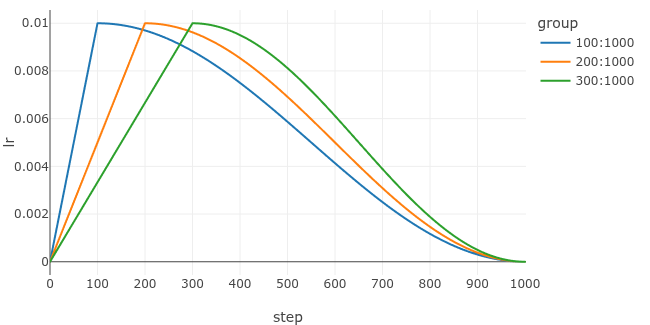

In [4]:
import pandas as pd; import torch; from torch.optim.lr_scheduler import LambdaLR; import plotly.express as px
import import_ipynb; from at2523 import cosine_schedule_with_warmup
def get_lr_curve(num_warmup_steps, num_training_steps):
    dummy_model = torch.nn.Linear(1, 1); results = []; base_lr = 0.01; num_steps = 1001
    optimizer = torch.optim.AdamW(dummy_model.parameters(), lr=base_lr, betas=(0.9, 0.98), eps=1e-9)
    lr_scheduler = cosine_schedule_with_warmup(optimizer=optimizer,
        num_warmup_steps=num_warmup_steps, num_training_steps=num_training_steps)
    for step in range(num_steps):
        lr = optimizer.param_groups[0]["lr"]; optimizer.step(); lr_scheduler.step()
        results.append({'step': step, 'lr': lr, 'group': f"{num_warmup_steps}:{num_training_steps}"})
    return pd.DataFrame(results)
def plot_lr_curve(df):
    fig = px.line(df, x="step", y="lr", color="group", template='none')
    xaxis = dict(tickmode='linear', tick0=0, dtick=100, range=[0, 1002]); width = 650; height = 325
    fig.update_layout(width=width, height=height, xaxis=xaxis, margin=dict(l=50,r=50,t=10,b=50))
    fig.show(renderer="png", width=width, height=height)
df1 = get_lr_curve(100, 1000); df2 = get_lr_curve(200, 1000); df3 = get_lr_curve(300, 1000)
plot_lr_curve(pd.concat([df1, df2, df3]))


<p style="page-break-after:always;"></p>


**Entrenamiento:**

In [ ]:
import torch; import torch.nn as nn; torch.manual_seed(23); import import_ipynb
from at251 import create_model, create_causal_mask; from at2523 import data_generator, cosine_schedule_with_warmup
V = 11; model = create_model(V, V, embed_dim=512, num_layers=2, num_heads=1, dropout=0.1)
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
model = model.to(device); model.train()
num_batches = 50; batch_size = 100; num_epochs = 20; num_training_steps = num_epochs * num_batches
warmup_ratio = 0.1; num_warmup_steps = int(num_training_steps * warmup_ratio)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
base_lr=0.001; optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, betas=(0.9, 0.98), eps=1e-9)
scheduler = cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)
for epoch in range(num_epochs):
    loss = 0; tokens = 0
    for i, batch in enumerate(data_generator(V, batch_size, nbatches=num_batches)):
        batch = batch.to(device); logits = model(batch.src, batch.tgt, batch.src_mask, batch.tgt_mask)
        y_pred = model.generator(logits)
        loss = criterion(y_pred.reshape(-1, y_pred.shape[-1]), batch.tgt_y.reshape(-1))
        loss.backward(); optimizer.step(); optimizer.zero_grad(set_to_none=True); scheduler.step()
        loss += loss.item(); tokens += batch.num_tokens
    if epoch % 5 == 0 or epoch == num_epochs-1:
        print(f"Epoch {epoch} loss {loss:<.4f} tokens {tokens} avg_loss {loss/tokens:g}")

Epoch 0 loss 4.7656 tokens 45000 avg_loss 0.000105903
Epoch 5 loss 1.3655 tokens 45000 avg_loss 3.03441e-05
Epoch 10 loss 1.1685 tokens 45000 avg_loss 2.59673e-05
Epoch 15 loss 1.1055 tokens 45000 avg_loss 2.45659e-05
Epoch 19 loss 1.0713 tokens 45000 avg_loss 2.38068e-05


In [8]:
model.eval(); src = torch.randint(1, 11, (1, 10)).to(device); src_mask = torch.ones(1, 1, 10).to(device)
memory = model.encode(src, src_mask); ys = torch.zeros(1, 1).type_as(src).to(device)
for i in range(9):
    tgt_mask = create_causal_mask(ys.size(1)).type_as(src.data)
    out = model.decode(ys, memory, src_mask, tgt_mask); prob = model.generator(out[:, -1])
    _, next_word = torch.max(prob, dim=1); next_word = next_word.data[0]
    ys = torch.cat([ys, torch.empty(1, 1).type_as(src.data).fill_(next_word)], dim=1)
print(f"{src}\n{ys}")

tensor([[10,  1,  5,  3,  3, 10,  3,  8,  7,  6]], device='cuda:0')
tensor([[ 0,  1,  5,  3,  3, 10,  3,  8,  7,  6]], device='cuda:0')



<p style="page-break-after:always;"></p>
